# Bank Customer Churn Prediction using Machine Learning

This project builds machine learning models to predict whether a bank customer will leave the bank (churn) based on demographic and financial attributes.

Models used:
- Logistic Regression
- Random Forest Classifier

The goal is to identify customers at risk of leaving so banks can implement targeted retention strategies.

## Dataset Overview

The dataset contains information about 10,000 bank customers and whether they exited the bank.

Key features include:

- Credit Score
- Geography
- Gender
- Age
- Tenure
- Account Balance
- Number of Products
- Active Membership Status
- Estimated Salary

Target Variable:
- **Exited**
  - 0 → Customer stayed
  - 1 → Customer left (churned)

In [99]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "Churn_Modelling.csv"))
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [100]:
df.shape

(10000, 14)

In [101]:
df.size

140000

## Data Inspection

We begin by examining the dataset structure, checking the number of rows, columns, and data types.

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [78]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Data Cleaning

Some columns do not provide useful information for prediction.

Removed columns:

- RowNumber
- CustomerId
- Surname

These are identifiers and do not influence churn behavior.

In [79]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [80]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [81]:
y = df["Exited"]
X = df.drop("Exited", axis=1)

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the dataset before training machine learning models.  
By visualizing the data, we can identify patterns, relationships between variables, and potential factors influencing customer churn.

### Customer Churn Distribution

This visualization shows the distribution of customers who stayed versus those who left the bank.

Understanding the class distribution is important because it helps identify whether the dataset is balanced or imbalanced.

Observation:
- Most customers remain with the bank.
- A smaller portion of customers churn.

This class imbalance can affect machine learning models and may require techniques such as class weighting or resampling to improve churn prediction.

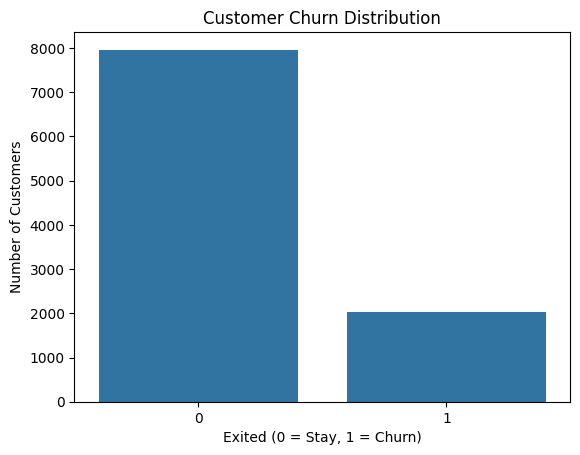

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stay, 1 = Churn)")
plt.ylabel("Number of Customers")
plt.show()

### Age vs Customer Churn

This boxplot compares the age distribution of customers who stayed versus those who churned.

Age is often an important factor in banking behavior. By analyzing this relationship, we can observe whether certain age groups are more likely to leave the bank.

Insights from this visualization help determine whether age is a strong predictor of churn.

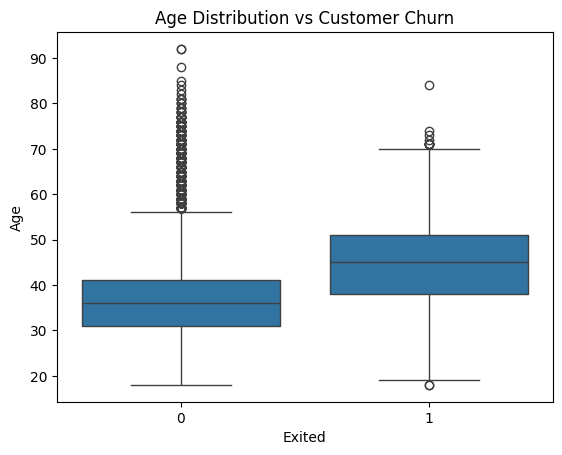

In [83]:
sns.boxplot(x="Exited", y="Age", data=df)

plt.title("Age Distribution vs Customer Churn")
plt.show()

### Account Balance vs Customer Churn

This boxplot compares the account balances of customers who stayed versus those who left.

Balance is an important financial indicator and may influence customer satisfaction and loyalty.  
Analyzing this relationship helps determine whether customers with higher balances are more likely to churn.

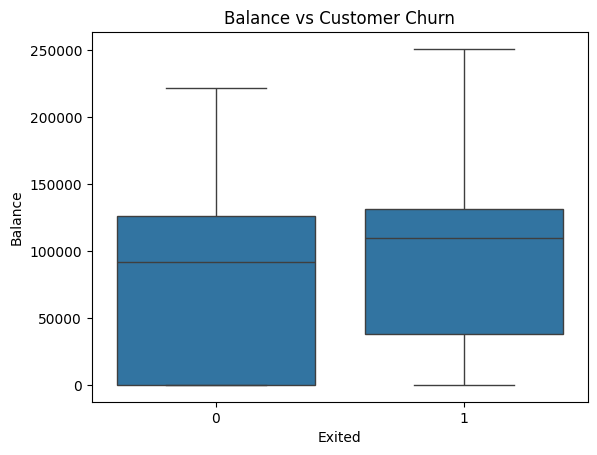

In [84]:
sns.boxplot(x="Exited", y="Balance", data=df)

plt.title("Balance vs Customer Churn")
plt.show()

## Feature Engineering

Categorical variables must be converted into numerical form before training machine learning models.

We apply **One-Hot Encoding** to:

- Geography
- Gender

In [85]:
X = pd.get_dummies(X, columns=["Geography", "Gender"], drop_first=True)

In [86]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


## Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

Training data is used to train the model, while testing data evaluates model performance.

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [88]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 11)
(2000, 11)
(8000,)
(2000,)


In [89]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


## Feature Scaling
Feature scaling is applied using StandardScaler because Logistic Regression is sensitive to differences in feature scales.

In [90]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

Logistic Regression is used as a baseline classification model.

Because features have different scales (salary vs age), we apply **feature scaling using StandardScaler**.

In [91]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [92]:
y_pred = model.predict(X_test_scaled)

## Model Evaluation

Model performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

In [93]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.811
[[1543   64]
 [ 314   79]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



## Random Forest Classifier

Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy.

It is capable of capturing complex non-linear relationships in the data.

In [94]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Model Evaluation

Model performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

In [95]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8695
[[1556   51]
 [ 210  183]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.78      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



## Model Comparison

| Model | Accuracy | Recall (Churn) | F1 Score |
|------|------|------|------|
| Logistic Regression | 81% | 20% | 0.29 |
| Random Forest | 87% | 47% | 0.58 |

Random Forest significantly improves churn detection compared to Logistic Regression.  
This demonstrates the advantage of ensemble models in capturing complex relationships within the data.

## Feature Importance Analysis

Random Forest allows us to measure how important each feature is in predicting churn.

This helps identify the main factors influencing customer exit behavior.

In [96]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance)


              feature  importance
1                 Age    0.252345
3             Balance    0.142832
7     EstimatedSalary    0.137891
4       NumOfProducts    0.134360
0         CreditScore    0.132716
2              Tenure    0.078925
6      IsActiveMember    0.037528
8   Geography_Germany    0.029481
10        Gender_Male    0.021511
5           HasCrCard    0.017942
9     Geography_Spain    0.014469


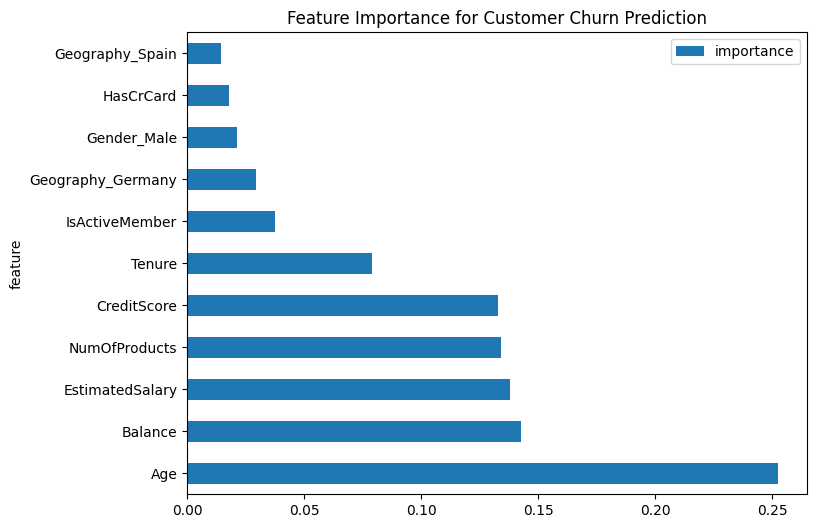

In [97]:
importance.plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance for Customer Churn Prediction")
plt.show()

In [98]:
import joblib
joblib.dump(rf, "churn_prediction_model.pkl")

['churn_prediction_model.pkl']

## Conclusion

Machine learning models were trained to predict customer churn using banking features such as credit score, balance, age, and activity status.

Logistic Regression achieved an accuracy of approximately **81%**, while Random Forest improved performance to **87% accuracy**.

Feature importance analysis showed that **Age, Balance, Estimated Salary, and Number of Products** were the strongest predictors of customer churn.

This project demonstrates how machine learning can help financial institutions identify high-risk customers and design targeted retention strategies.